# 使用Python求解多元一次方程组
设有以下方程组:
- $2x+3y-z=1$
- $4x-y+5z=7$
- $-x +2y +2z = 3$

1. 请使用`numpy`库求解以上方程组中 $x, y, z$的值
2. 拓展：使用`scipy`求解，比较结果

In [9]:
# 导入 numpy 库
import numpy as np

# 系数矩阵
A = np.array([[2, 3, -1],
              [4, -1, 5],
              [-1, 2, 2]])

# 常数矩阵
B = np.array([1, 7, 3])

# 求解线性方程组
solution = np.linalg.solve(A, B)

# 输出解
print("方程组的解为: x =", solution[0], ", y =", solution[1], ", z =", solution[2])

# 使用 scipy.linalg.solve() 求解
from scipy.linalg import solve
solution_scipy = solve(A, B)
print("使用 scipy.linalg.solve() 解得的结果为:", solution_scipy)


方程组的解为: x = 0.37142857142857144 , y = 0.48571428571428565 , z = 1.2
使用 scipy.linalg.solve() 解得的结果为: [0.37142857 0.48571429 1.2       ]


# 多元函数拟合

给定一组二维数据点，如下所示
- $X= \{[1,1],[2,4],[3,9],[4,16],[5,25]\}$
- $Y= \{1.2,2.8,4.9,8.2,11.9\}$

请使用线性回归模型来拟合这个数据，使用`scikit-learn`中的`LinearRegression`类来完成.

要求：
- 拟合后输出线性模型的系数和截距。
- 绘制数据点和拟合直线的图像。

线性模型的系数: [0.36571429 0.38571429]
线性模型的截距: 0.4599999999999991


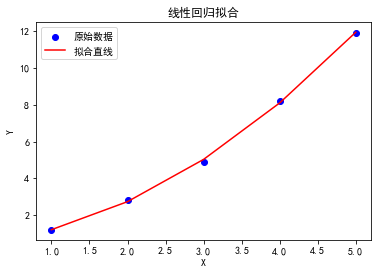

In [10]:
# 导入所需库
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 数据集
X = np.array([[1, 1], [2, 4], [3, 9], [4, 16], [5, 25]])
Y = np.array([1.2, 2.8, 4.9, 8.2, 11.9])

# 创建线性回归模型
model = LinearRegression()

# 训练模型
model.fit(X, Y)

# 输出模型参数
print("线性模型的系数:", model.coef_)
print("线性模型的截距:", model.intercept_)

# 预测
Y_pred = model.predict(X)

# 绘制原始数据点和拟合线
plt.scatter(X[:, 0], Y, color='blue', label='原始数据')
plt.plot(X[:, 0], Y_pred, color='red', label='拟合直线')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.title('线性回归拟合')
plt.show()


练习描述：

基于上述数据，尝试使用多项式回归拟合，并绘制数据点和拟合曲线的图像。

要求：

- 使用`PolynomialFeatures`和`LinearRegression`来完成多项式回归。
- 比较不同阶数的多项式拟合效果，例如二次和三次多项式。

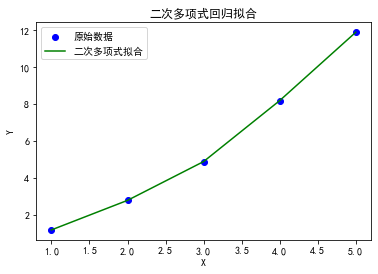

In [11]:
# 导入多项式回归相关库
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# 创建二次多项式回归模型
poly_model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())

# 训练模型
poly_model.fit(X, Y)

# 预测
Y_poly_pred = poly_model.predict(X)

# 绘制原始数据点和多项式拟合曲线
plt.scatter(X[:, 0], Y, color='blue', label='原始数据')
plt.plot(X[:, 0], Y_poly_pred, color='green', label='二次多项式拟合')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.title('二次多项式回归拟合')
plt.show()


# 使用插值方法对数据进行插值

练习描述：
给定一个季度数据集，表示季度的收入（单位：千元）：
- Q1: 120
- Q2: 135
- Q3: 150
- Q4: 165

请使用Python的`scipy`库中的插值方法，将这些季度数据插值为月度数据。

要求：
- 使用scipy.interpolate.interp1d进行线性插值，并输出每个月的收入数据。
- 通过绘图展示季度数据点和插值生成的月度数据点。

扩展：
- 尝试使用不同的插值方法（如样条插值CubicSpline）进行插值，比较不同方法的插值效果。

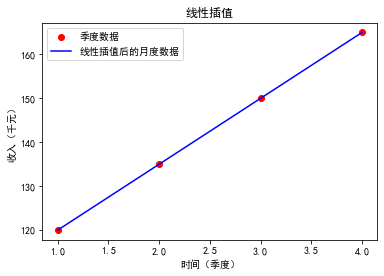

In [12]:
# 导入所需库
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# 季度数据
quarters = np.array([1, 2, 3, 4])
revenue = np.array([120, 135, 150, 165])

# 线性插值
interp_function = interp1d(quarters, revenue, kind='linear')

# 定义月度数据点
months = np.linspace(1, 4, 12)

# 进行插值
monthly_revenue = interp_function(months)

# 绘制季度数据和插值后的月度数据
plt.scatter(quarters, revenue, color='red', label='季度数据')
plt.plot(months, monthly_revenue, color='blue', label='线性插值后的月度数据')
plt.xlabel('时间（季度）')
plt.ylabel('收入（千元）')
plt.legend()
plt.title('线性插值')
plt.show()


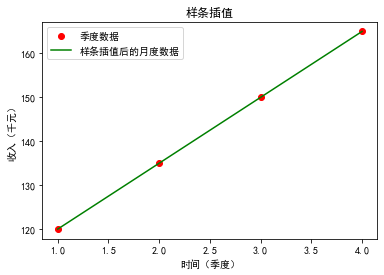

In [13]:
# 导入样条插值库
from scipy.interpolate import CubicSpline

# 样条插值
cubic_spline = CubicSpline(quarters, revenue)

# 使用样条插值生成月度数据
monthly_revenue_spline = cubic_spline(months)

# 绘制季度数据和样条插值后的月度数据
plt.scatter(quarters, revenue, color='red', label='季度数据')
plt.plot(months, monthly_revenue_spline, color='green', label='样条插值后的月度数据')
plt.xlabel('时间（季度）')
plt.ylabel('收入（千元）')
plt.legend()
plt.title('样条插值')
plt.show()


# 使用蒙特卡洛方法估计圆周率$\pi$

估计的π值为: 3.14328


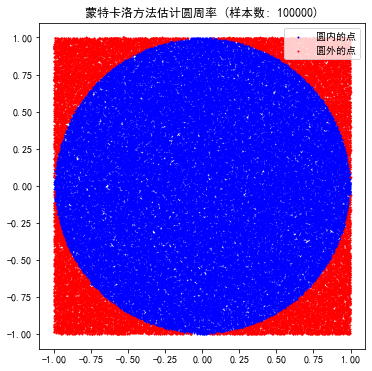

In [16]:
import numpy as np
import matplotlib.pyplot as plt

def estimate_pi(num_samples):
    # 随机生成 num_samples 个 (x, y) 点，范围在 [-1, 1]
    x = np.random.uniform(-1, 1, num_samples)
    y = np.random.uniform(-1, 1, num_samples)

    # 计算每个点到原点的距离，判断是否在圆内
    distances = np.sqrt(x**2 + y**2)
    inside_circle = distances <= 1

    # 圆内的点数
    num_inside_circle = np.sum(inside_circle)

    # 估计π的值
    pi_estimate = 4 * num_inside_circle / num_samples

    return pi_estimate

# 设置采样点数
num_samples = 100000

# 估计π
pi_estimated = estimate_pi(num_samples)
print(f"估计的π值为: {pi_estimated}")

# 可视化随机点
x = np.random.uniform(-1, 1, num_samples)
y = np.random.uniform(-1, 1, num_samples)
inside_circle = np.sqrt(x**2 + y**2) <= 1

plt.figure(figsize=(6,6))
plt.scatter(x[inside_circle], y[inside_circle], color='blue', s=1, label='圆内的点')
plt.scatter(x[~inside_circle], y[~inside_circle], color='red', s=1, label='圆外的点')
plt.gca().set_aspect('equal', adjustable='box')
plt.title(f"蒙特卡洛方法估计圆周率 (样本数: {num_samples})")
plt.legend()
plt.show()


# 投资组合优化练习

练习描述：
你被要求优化一个包含五个资产的投资组合，目标是最大化夏普比率。在这之前，你需要生成这五个资产的历史收益率时间序列数据，并计算出最优的资产权重分配。

- 步骤 1: 生成资产的收益率时间序列

    - 使用numpy库生成5个资产的日收益率时间序列，每个资产有250个交易日的数据。假设这些收益率是从正态分布中生成的，均值为0.0005，标准差为0.01。

    - 生成的收益率数据形状为(250, 5)，其中每列代表一个资产，每行为一个交易日。

- 步骤 2: 计算投资组合的预期收益和风险
    - 使用生成的收益率数据，计算每个资产的平均日收益率和协方差矩阵。

    - 随机生成数千个投资组合权重（假设每个资产的权重在0到1之间，总和为1），计算每个组合的预期收益率和风险（标准差）。

- 步骤 3: 最大化夏普比率

    - 对每个投资组合计算夏普比率（假设无风险利率为0）。

    - 找到夏普比率最高的投资组合，并输出该组合的资产权重。

额外要求：
- 绘制所有投资组合的收益与风险的散点图，并标记夏普比率最高的组合。
- 输出最优组合的夏普比率、预期收益率和风险。

扩展任务：

- 引入资产之间的交易费用，重新计算最优的投资组合权重。（删除）
- 假设资产的历史收益率服从不同分布（例如，某些资产的收益率服从对数正态分布），重新生成数据，并重新优化组合。


In [2]:
import numpy as np

# 设置随机种子以确保结果可重复
np.random.seed(42)

# 生成250天5个资产的收益率（正态分布，均值0.0005，标准差0.01）
returns = np.random.normal(0.0005, 0.01, (250, 5))

# 打印生成的收益率数据
print(returns)


[[ 0.00546714 -0.00088264  0.00697689  0.0157303  -0.00184153]
 [-0.00184137  0.01629213  0.00817435 -0.00419474  0.0059256 ]
 [-0.00413418 -0.0041573   0.00291962 -0.0186328  -0.01674918]
 ...
 [ 0.01689117  0.01727701 -0.00503588  0.00618983  0.01678397]
 [-0.00329128 -0.0015358  -0.00531681 -0.00964757 -0.00599278]
 [-0.0117394   0.00084083 -0.00719973  0.00283786 -0.01505896]]


In [3]:
# 计算每个资产的平均收益率
mean_returns = np.mean(returns, axis=0)

# 计算收益率的协方差矩阵
cov_matrix = np.cov(returns, rowvar=False)

# 随机生成组合权重
def random_weights(num_assets):
    weights = np.random.random(num_assets)
    return weights / np.sum(weights)

# 计算组合的预期收益和风险
def portfolio_performance(weights, mean_returns, cov_matrix):
    # 预期收益
    portfolio_return = np.sum(weights * mean_returns)
    
    # 组合方差
    portfolio_variance = np.dot(weights.T, np.dot(cov_matrix, weights))
    
    # 组合标准差（风险）
    portfolio_stddev = np.sqrt(portfolio_variance)
    
    return portfolio_return, portfolio_stddev

# 生成一个随机组合的权重
weights = random_weights(5)

# 计算该组合的预期收益和风险
portfolio_return, portfolio_stddev = portfolio_performance(weights, mean_returns, cov_matrix)

# 输出结果
print("组合的预期收益率:", portfolio_return)
print("组合的风险（标准差）:", portfolio_stddev)

组合的预期收益率: 0.0007206102049537298
组合的风险（标准差）: 0.004791313997635199


最优组合的权重: [0.16909298 0.02647513 0.09004152 0.35447964 0.35991073]
最优组合的预期收益率: 0.0012606762154321158
最优组合的风险（标准差）: 0.005355087231585312
最优组合的夏普比率: 0.23541656016290644


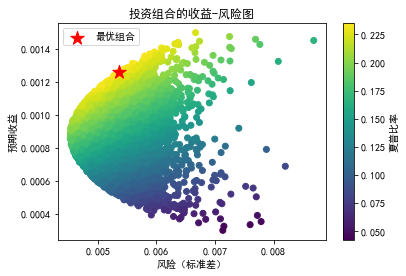

In [8]:
import matplotlib.pyplot as plt
# 设置全局字体为支持中文的字体
from matplotlib import rcParams
rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体 (SimHei) 字体
rcParams['axes.unicode_minus'] = False    # 解决负号显示问题

# 无风险利率
risk_free_rate = 0

# 计算组合的夏普比率
def sharpe_ratio(portfolio_return, portfolio_stddev, risk_free_rate):
    return (portfolio_return - risk_free_rate) / portfolio_stddev

# 模拟多个组合
num_portfolios = 10000
results = np.zeros((num_portfolios, 3))  # 存储收益、风险和夏普比率
weights_record = []

for i in range(num_portfolios):
    weights = random_weights(5)  # 生成组合权重
    portfolio_return, portfolio_stddev = portfolio_performance(weights, mean_returns, cov_matrix)
    sr = sharpe_ratio(portfolio_return, portfolio_stddev, risk_free_rate)
    
    # 记录组合的收益、风险和夏普比率
    results[i] = [portfolio_return, portfolio_stddev, sr]
    weights_record.append(weights)

# 找到夏普比率最高的组合
max_sharpe_idx = np.argmax(results[:, 2])
max_sharpe_portfolio = results[max_sharpe_idx]
best_weights = weights_record[max_sharpe_idx]

# 输出最优组合结果
print("最优组合的权重:", best_weights)
print("最优组合的预期收益率:", max_sharpe_portfolio[0])
print("最优组合的风险（标准差）:", max_sharpe_portfolio[1])
print("最优组合的夏普比率:", max_sharpe_portfolio[2])

# 绘制所有组合的收益与风险的散点图
plt.scatter(results[:, 1], results[:, 0], c=results[:, 2], cmap='viridis', marker='o')
plt.colorbar(label='夏普比率')
plt.xlabel('风险（标准差）')
plt.ylabel('预期收益')

# 标记夏普比率最高的组合
plt.scatter(max_sharpe_portfolio[1], max_sharpe_portfolio[0], color='red', marker='*', s=200, label='最优组合')
plt.legend()
plt.title('投资组合的收益-风险图')
plt.show()

In [15]:
from scipy.optimize import minimize

# 计算组合的负夏普比率（作为目标函数）
def negative_sharpe_ratio(weights, mean_returns, cov_matrix, risk_free_rate):
    portfolio_return, portfolio_stddev = portfolio_performance(weights, mean_returns, cov_matrix)
    return -(portfolio_return - risk_free_rate) / portfolio_stddev  # 求负的Sharpe比率

# 约束：所有权重的和必须为1
def constraint(weights):
    return np.sum(weights) - 1

# 设置权重范围：0到1
bounds = tuple((0, 1) for _ in range(5))

# 初始权重
initial_weights = np.ones(5) / 5

# 定义约束条件
constraints = {'type': 'eq', 'fun': constraint}

# 使用优化器寻找最优组合
opt_results = minimize(negative_sharpe_ratio, initial_weights, args=(mean_returns, cov_matrix, risk_free_rate),
                       method='SLSQP', bounds=bounds, constraints=constraints)

# 获取最优权重
optimal_weights = opt_results.x

# 计算最优组合的收益、风险和夏普比率
optimal_return, optimal_stddev = portfolio_performance(optimal_weights, mean_returns, cov_matrix)
optimal_sharpe_ratio = -opt_results.fun

# 输出结果
print("最优组合的权重:", optimal_weights)
print("最优组合的预期收益率:", optimal_return)
print("最优组合的风险（标准差）:", optimal_stddev)
print("最优组合的夏普比率:", optimal_sharpe_ratio)

最优组合的权重: [0.16458548 0.0074765  0.0893476  0.35969374 0.37889668]
最优组合的预期收益率: 0.0012948163886227465
最优组合的风险（标准差）: 0.0054948622021533675
最优组合的夏普比率: 0.2356412847105291


# 一般效用函数作为优化目标

一般形式的效用函数：
$$ U(w)=λ⋅μ_p −(1−λ)⋅σ_p$$
其中：
- U(w) 是效用函数， 𝑤是投资组合的权重。
- μ_p 是投资组合的预期收益率，计算方式为：$𝜇_𝑝 = 𝑤^𝑇 ⋅ 𝜇$, 其中 𝜇是各个资产的平均收益率。
- σ_p是投资组合的波动率（风险)
- λ 是风险偏好参数，取值范围为 [0, 1]，表示投资者对收益与风险的权衡。通常，如果 λ 较高，表示更偏好高收益；如果 λ 较低，表示更重视低风险。

如果设置$\lambda=0.5$, 通过最大化这个效用函数来找到最优的权重 $w$。

In [ ]:

# 效用函数：收益均值和波动率的综合加权
def utility_function(weights, mean_returns, cov_matrix, lambda_risk_preference):
    portfolio_return, portfolio_stddev = portfolio_performance(weights, mean_returns, cov_matrix)
    
    # 效用函数：收益 - 风险
    utility = lambda_risk_preference * portfolio_return - (1 - lambda_risk_preference) * portfolio_stddev
    return -utility  # 最大化效用相当于最小化负效用

# 约束：所有权重的和必须为1
def constraint(weights):
    return np.sum(weights) - 1

# 设置权重范围：0到1
bounds = tuple((0, 1) for _ in range(5))

# 初始权重
initial_weights = np.ones(5) / 5

# 定义约束条件
constraints = {'type': 'eq', 'fun': constraint}

labmda_risk_preference = 0.5

# 使用优化器寻找最优组合
opt_results = minimize(utility_function, initial_weights, args=(mean_returns, cov_matrix, lambda_risk_preference),
                       method='SLSQP', bounds=bounds, constraints=constraints)

# 获取最优权重
optimal_weights = opt_results.x

# 计算最优组合的收益、风险和效用
optimal_return, optimal_stddev = portfolio_performance(optimal_weights, mean_returns, cov_matrix)
optimal_utility = -opt_results.fun

# 输出结果
print("最优组合的权重:", optimal_weights)
print("最优组合的预期收益率:", optimal_return)
print("最优组合的风险（标准差）:", optimal_stddev)
print("最优组合的效用值:", optimal_utility)